In [2]:
# 🚗 Drowsy Driver Detection using CNN

#This notebook trains a CNN to classify eye images as "open" or "closed" using a structured dataset.
#The goal is to detect drowsiness in real-time using a webcam integrated with Haar cascades and a trained deep learning model.


In [17]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


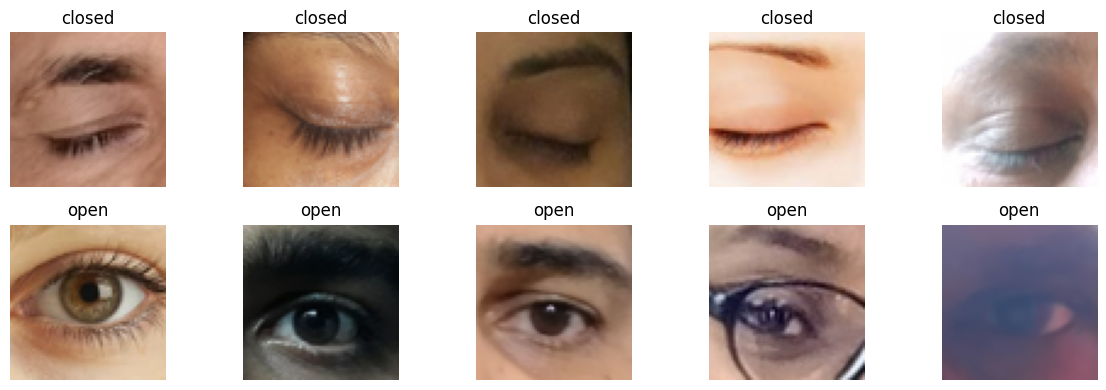

In [18]:
def show_random_images(base_dir, categories, samples_per_class=5):
    plt.figure(figsize=(12, 4))
    for idx, category in enumerate(categories):
        folder = os.path.join(base_dir, category)
        images = os.listdir(folder)
        random_imgs = random.sample(images, samples_per_class)
        for i, img_name in enumerate(random_imgs):
            img_path = os.path.join(folder, img_name)
            img = Image.open(img_path).resize((64, 64))
            plt.subplot(len(categories), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(category)
    plt.tight_layout()
    plt.show()

show_random_images("dataset/train", ["closed", "open"])


In [19]:
train_path = "dataset/train"
test_path = "dataset/test"

train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, shear_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important for confusion matrix
)


Found 1247 images belonging to 2 classes.
Found 218 images belonging to 2 classes.


In [20]:
print("Class indices:", train_generator.class_indices)


Class indices: {'Closed': 0, 'Open': 1}


In [21]:
import collections

# Check how many images per class
print("Train class counts:", dict(collections.Counter(train_generator.classes)))
print("Test class counts:", dict(collections.Counter(test_generator.classes)))


Train class counts: {np.int32(0): 617, np.int32(1): 630}
Test class counts: {np.int32(0): 109, np.int32(1): 109}


In [22]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_drowsy_model.h5", save_best_only=True)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Two classes: closed and open
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\91733\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,625,410 (6.20 MB)

 Trainable params: 1,625,410 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint]
)


C:\Users\91733\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.5286 - loss: 0.7830

39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 281ms/step - accuracy: 0.5305 - loss: 0.7801 - val_accuracy: 0.7706 - val_loss: 0.4472
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8866 - loss: 0.3145

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.8869 - loss: 0.3133 - val_accuracy: 0.9450 - val_loss: 0.1604
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - accuracy: 0.9190 - loss: 0.1835 - val_accuracy: 0.9450 - val_loss: 0.1718
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.9327 - loss: 0.1636 - val_accuracy: 0.9541 - val_loss: 0.1670
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9419 - loss: 0.1582

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - accuracy: 0.9419 - loss: 0.1583 - val_accuracy: 0.9633 - val_loss: 0.1057
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 289ms/step - accuracy: 0.9634 - loss: 0.0971 - val_accuracy: 0.9404 - val_loss: 0.1218
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9566 - loss: 0.1011

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.9567 - loss: 0.1012 - val_accuracy: 0.9679 - val_loss: 0.1027
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.9655 - loss: 0.1007 - val_accuracy: 0.9450 - val_loss: 0.1257
Epoch 9/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.9615 - loss: 0.0877 - val_accuracy: 0.9541 - val_loss: 0.1079
Epoch 10/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 269ms/step - accuracy: 0.9712 - loss: 0.0887 - val_accuracy: 0.9587 - val_loss: 0.1328


In [24]:
final_acc = history.history['val_accuracy'][-1]
print(f"\n✅ Final Validation Accuracy: {final_acc * 100:.2f}%")



✅ Final Validation Accuracy: 95.87%


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step


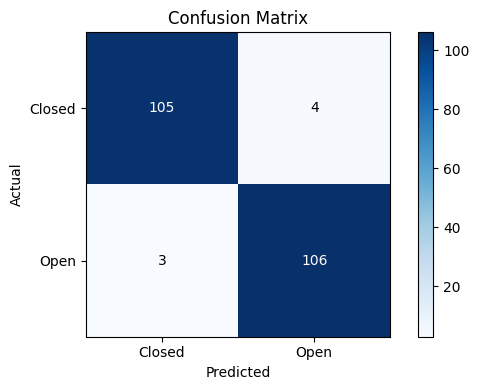


📋 Classification Report:

              precision    recall  f1-score   support

      Closed       0.97      0.96      0.97       109
        Open       0.96      0.97      0.97       109

    accuracy                           0.97       218
   macro avg       0.97      0.97      0.97       218
weighted avg       0.97      0.97      0.97       218



In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
labels = ['Closed', 'Open']

plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

# Add labels to each square
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Report
print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=labels))


In [28]:
model.save("drowsy_model_final.h5")


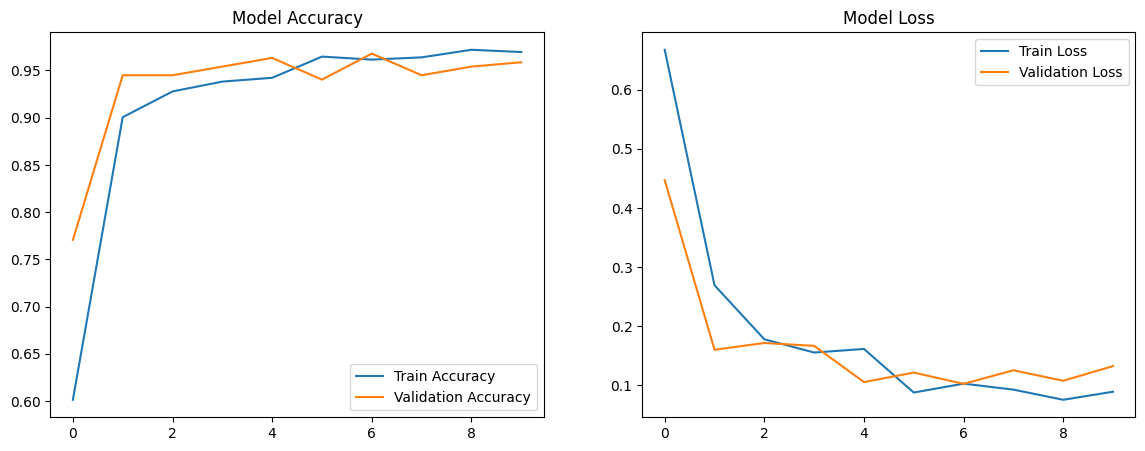

In [27]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.legend()

plt.show()
